In [1]:
import os
import xarray as xr
import pandas as pd

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

#ds = xr.open_mfdataset(nc_files, combine='by_coords')  # or combine='nested' with concat_dim='time' if needed
ds_sealevel = xr.open_dataset("/Users/lb962/Documents/GitHub/ESL/data/processed/filtered_GESLA_sea_level.nc")
# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['latitude'].values
lons = ds_sealevel['longitude'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

In [2]:
# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    ds_masked = ds_tile.copy()
    ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)
    return ds_masked

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.where(
        (ds.lat >= lat - half) & (ds.lat <= lat + half) &
        (ds.lon >= lon - half) & (ds.lon <= lon + half),
        drop=True  # drops points outside the box
    )
for lat, lon in unique_latlon:
    results["0.1x0.1"].append(extract_square(GEBCO_ds, lat, lon, 0.1))
    results["0.25x0.25"].append(extract_square(GEBCO_ds, lat, lon, 0.25))
    results["1x1"].append(extract_square(GEBCO_ds, lat, lon, 1))
    results["3x3"].append(extract_square(GEBCO_ds, lat, lon, 3))
    results["10x10"].append(extract_square(GEBCO_ds, lat, lon, 10))


KeyboardInterrupt: 

In [ ]:
results

{'0.1x0.1': [<xarray.Dataset>
  Dimensions:    (lat: 24, lon: 24)
  Coordinates:
    * lat        (lat) float64 60.11 60.11 60.11 60.12 ... 60.19 60.19 60.2 60.2
    * lon        (lon) float64 -1.19 -1.185 -1.181 -1.177 ... -1.102 -1.098 -1.094
  Data variables:
      elevation  (lat, lon) float32 -46.0 -43.0 -42.0 -42.0 ... -47.0 -48.0 -49.0
  Attributes: (12/36)
      title:                           The GEBCO_2024 Grid - a continuous terra...
      summary:                         The GEBCO_2024 Grid is a continuous, glo...
      keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
      Conventions:                     CF-1.6, ACDD-1.3
      id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
      naming_authority:                https://dx.doi.org
      ...                              ...
      geospatial_vertical_units:       meters
      geospatial_vertical_resolution:  1.0
      geospatial_vertical_positive:    up
      identif

In [4]:
del GEBCO_ds

# Train generic auto encoder

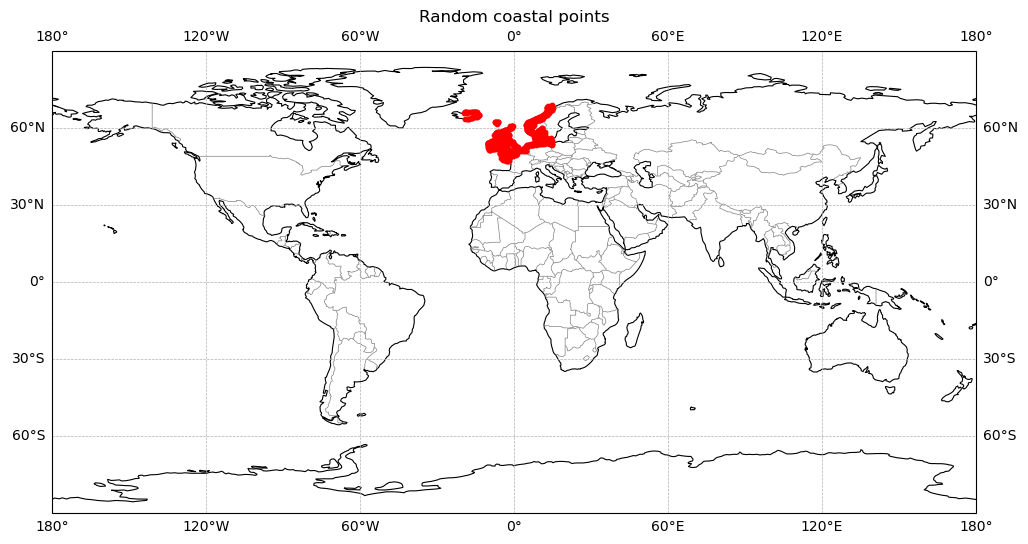

In [6]:
import numpy as np
from cartopy.io import shapereader
from shapely.geometry import LineString, MultiLineString
import pyproj

def _coastline_segments(resolution="10m"):
    shp = shapereader.natural_earth(resolution=resolution, category="physical", name="coastline")
    reader = shapereader.Reader(shp)
    geod = pyproj.Geod(ellps="WGS84")
    for geom in reader.geometries():
        lines = [geom] if isinstance(geom, LineString) else (list(geom.geoms) if isinstance(geom, MultiLineString) else [])
        for ln in lines:
            coords = list(ln.coords)
            for (lon1, lat1), (lon2, lat2) in zip(coords[:-1], coords[1:]):
                if (lat1 == lat2) and (lon1 == lon2):
                    continue
                _, _, dist_m = geod.inv(lon1, lat1, lon2, lat2)
                if dist_m <= 0:
                    continue
                yield lon1, lat1, lon2, lat2, dist_m / 1000.0

def _interp_on_segment(lon1, lat1, lon2, lat2, t):
    dlon = ((lon2 - lon1 + 180) % 360) - 180
    lon = lon1 + t * dlon
    lat = lat1 + t * (lat2 - lat1)
    lon = ((lon + 180) % 360) - 180
    return lon, lat

def random_coastal_points_cartopy_in_GEBCO(
    GEBCO_ds,
    n_points=200,
    margin_km=20,
    seed=0,
    resolution="10m",
    dedup_km=5,
    require_valid_elevation=False
):
    """
    Sample exactly n_points coastal (lat, lon) pairs that lie INSIDE GEBCO_ds coverage.
    - margin_km: jitter distance from coastline (0 => exactly on coastline)
    - dedup_km: min spacing (approximate) to avoid near-duplicates
    - require_valid_elevation: if True, also ensures GEBCO_ds['elevation'] is finite at the nearest grid cell
    """
    rng = np.random.default_rng(seed)
    geod = pyproj.Geod(ellps="WGS84")

    # Build segment table once
    seg_lons1, seg_lats1, seg_lons2, seg_lats2, seg_lengths = [], [], [], [], []
    for lon1, lat1, lon2, lat2, L in _coastline_segments(resolution=resolution):
        seg_lons1.append(lon1); seg_lats1.append(lat1)
        seg_lons2.append(lon2); seg_lats2.append(lat2)
        seg_lengths.append(L)

    seg_lons1 = np.asarray(seg_lons1, float)
    seg_lats1 = np.asarray(seg_lats1, float)
    seg_lons2 = np.asarray(seg_lons2, float)
    seg_lats2 = np.asarray(seg_lats2, float)
    seg_lengths = np.asarray(seg_lengths, float)
    if seg_lengths.size == 0:
        raise RuntimeError("No coastline segments found.")

    probs = seg_lengths / seg_lengths.sum()

    # GEBCO bounds + lon normalizer
    lat_min = float(GEBCO_ds.lat.min()); lat_max = float(GEBCO_ds.lat.max())
    lon_min = float(GEBCO_ds.lon.min()); lon_max = float(GEBCO_ds.lon.max())
    lon_to_grid = (lambda lo: lo % 360) if lon_max > 180 else (lambda lo: ((lo + 180) % 360) - 180)

    # Dedup helper
    def _quant_key(lat, lon):
        lat_q = int(np.round(lat / (dedup_km / 111.0)))
        lon_scale = max(1e-6, np.cos(np.deg2rad(lat)))
        lon_q = int(np.round(lon / (dedup_km / (111.0 * lon_scale))))
        return (lat_q, lon_q)

    pts, seen = [], set()
    attempts, max_attempts = 0, n_points * 500  # generous headroom

    # Optional: fast indexers
    lat_vals = np.asarray(GEBCO_ds.lat.values)
    lon_vals = np.asarray(GEBCO_ds.lon.values)

    def _inside_bounds(la, lo):
        lo_g = lon_to_grid(lo)
        return (lat_min <= la <= lat_max) and (lon_min <= lo_g <= lon_max)

    def _has_valid_elev(la, lo):
        # nearest-neighbor check
        lo_g = lon_to_grid(lo)
        i = np.abs(lat_vals - la).argmin()
        j = np.abs(lon_vals - lo_g).argmin()
        val = GEBCO_ds["elevation"].values[i, j]
        return np.isfinite(val)

    while len(pts) < n_points and attempts < max_attempts:
        attempts += 1
        idx = rng.choice(seg_lengths.size, p=probs)
        t = rng.random()
        lon0, lat0 = _interp_on_segment(seg_lons1[idx], seg_lats1[idx], seg_lons2[idx], seg_lats2[idx], t)

        # jitter
        if margin_km and margin_km > 0:
            az = rng.uniform(0, 360)
            r = margin_km * np.sqrt(rng.random())
            lon1, lat1, _ = geod.fwd(lon0, lat0, az, r * 1000.0)
        else:
            lon1, lat1 = lon0, lat0

        if not (-85 <= lat1 <= 85):
            continue
        if not _inside_bounds(lat1, lon1):
            continue
        if require_valid_elevation and not _has_valid_elev(lat1, lon1):
            continue

        key = _quant_key(lat1, lon1)
        if key in seen:
            continue
        seen.add(key)
        pts.append((lat1, lon1))

    if len(pts) < n_points:
        raise RuntimeError(
            f"Could only place {len(pts)} / {n_points} points inside GEBCO bounds. "
            f"Consider reducing dedup_km, increasing margin_km, or raising max_attempts."
        )

    return pts

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_random_points(points, title="Random coastal points"):
    """
    Plot random coastal (lat, lon) points on a global map with coastlines.
    """
    lats, lons = zip(*points)

    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="gray")
    ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--")

    # Scatter points
    ax.scatter(lons, lats, color="red", s=10, transform=ccrs.PlateCarree(), zorder=5)
    ax.set_title(title)
    plt.show()


# Exactly 1000 points inside GEBCO coverage (and on/near coastlines)
random_points = random_coastal_points_cartopy_in_GEBCO(
    GEBCO_ds,
    n_points=1000,
    margin_km=25,
    seed=2025,
    resolution="10m",
    dedup_km=5,
    require_valid_elevation=True
)

plot_random_points(random_points )

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    ds_masked = ds_tile.copy()
    ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)
    return ds_masked

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.where(
        (ds.lat >= lat - half) & (ds.lat <= lat + half) &
        (ds.lon >= lon - half) & (ds.lon <= lon + half),
        drop=True  # drops points outside the box
    )


# Available resolutions
resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]
rng = np.random.default_rng(seed=123)

# Initialize results dict if not done already
results = {f"{r}x{r}": [] for r in resolutions}

for lat, lon in random_points:
    # Pick one resolution at random for this (lat, lon)
    size = (rng.choice(resolutions))
    key = f"{size}x{size}"
   # results["10x10"].append(extract_square(GEBCO_ds, lat, lon, 10))
    results[key].append(extract_square(GEBCO_ds, lat, lon, size))

Plotting 2 tiles from 0.1x0.1


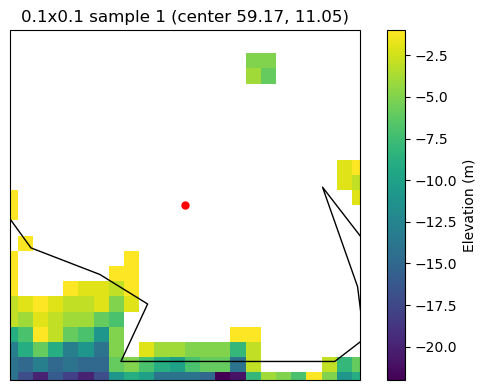

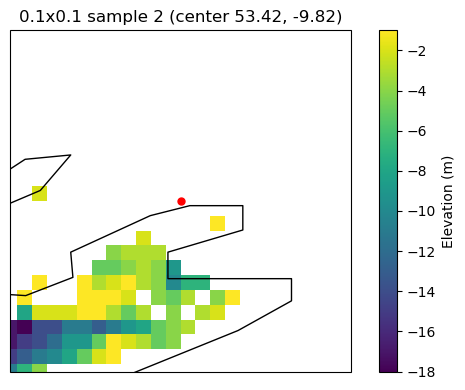

Plotting 2 tiles from 0.25x0.25


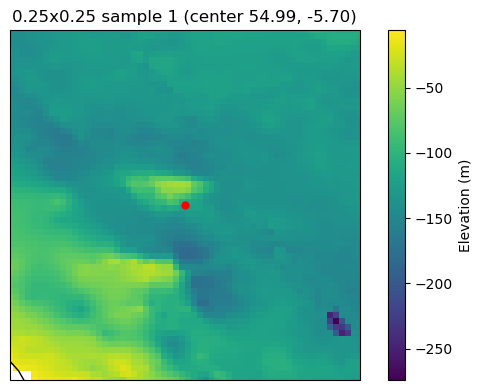

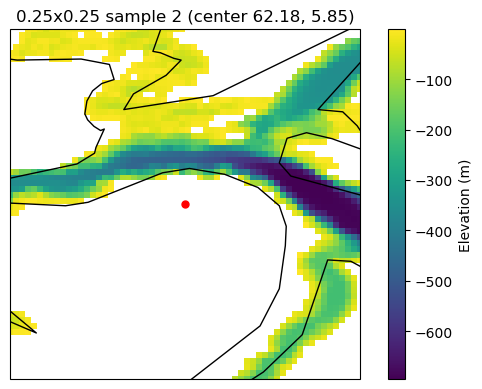

Plotting 2 tiles from 1.0x1.0


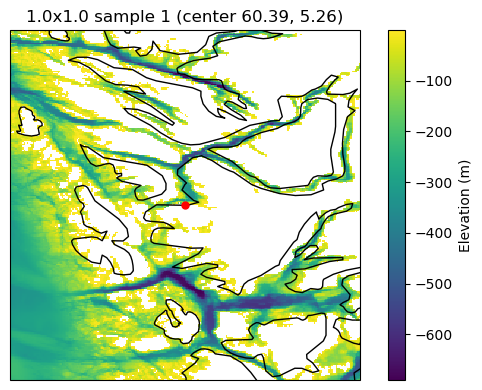

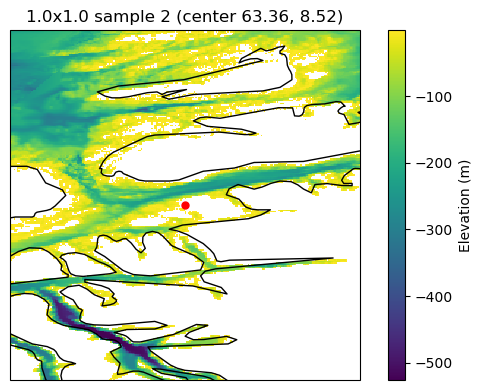

Plotting 2 tiles from 3.0x3.0


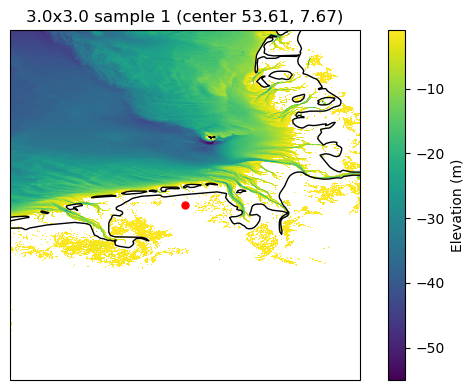

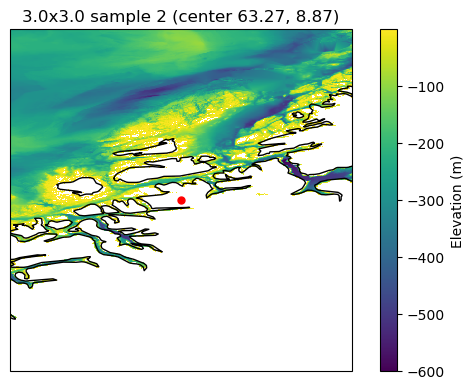

Plotting 2 tiles from 10.0x10.0


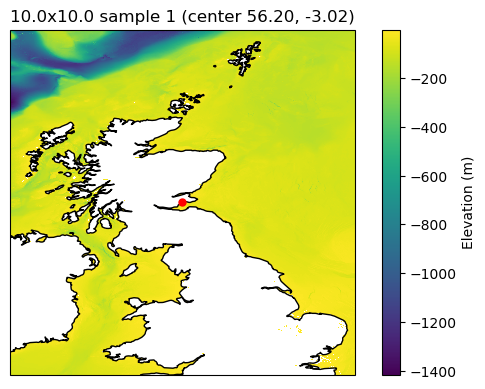

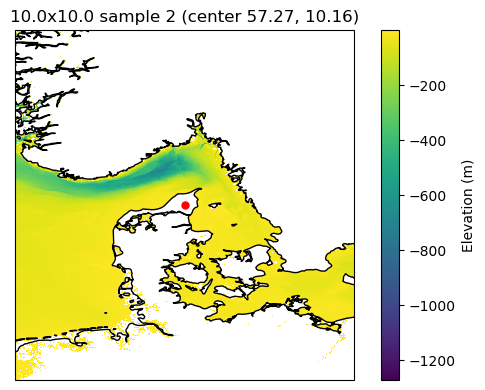

In [55]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_results_bathymetry(results, max_per_size=3):
    """
    Plot bathymetry tiles stored in results dict using Cartopy.
    Shows up to max_per_size per resolution bin.
    """
    for key, tiles in results.items():
        if not tiles:
            print(f"No tiles in {key}")
            continue
        
        print(f"Plotting {min(len(tiles), max_per_size)} tiles from {key}")
        for i, ds_tile in enumerate(tiles[:max_per_size]):
            # mask shallow elevations
            ds_masked = ds_tile.copy()
            ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)

            # compute tile center
            center_lat = float(ds_masked.lat.mean())
            center_lon = float(ds_masked.lon.mean())

            fig = plt.figure(figsize=(6, 4))
            ax = plt.axes(projection=ccrs.PlateCarree())

            pcm = ax.pcolormesh(
                ds_masked["lon"], ds_masked["lat"], ds_masked["elevation"],
                transform=ccrs.PlateCarree()
            )

            ax.coastlines(resolution="10m")
            ax.set_extent([
                float(ds_masked.lon.min()), float(ds_masked.lon.max()),
                float(ds_masked.lat.min()), float(ds_masked.lat.max())
            ], crs=ccrs.PlateCarree())
            ax.set_title(f"{key} sample {i+1} (center {center_lat:.2f}, {center_lon:.2f})")
            ax.plot(center_lon, center_lat, "ro", markersize=5, transform=ccrs.PlateCarree())

            plt.colorbar(pcm, ax=ax, label="Elevation (m)")
            plt.tight_layout()
            plt.show()

# Example usage
plot_results_bathymetry(results, max_per_size=2)

In [48]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

def try_collect_tiles_from_results():
    """Collect 2D elevation arrays from results[...] xarray tiles."""
    if "results" not in globals():
        raise NameError("`results` not found in globals.")
    key = "1x1" if "1x1" in results and results["1x1"] else next(iter(results.keys()))
    tiles = []
    for ds in results[key]:
        if "elevation" not in ds:
            continue
        arr = np.array(ds["elevation"].values)
        if arr.ndim == 2:
            tiles.append(arr.astype(np.float32))
    if not tiles:
        raise ValueError("No usable 2D elevation arrays found in results.")
    return tiles, f"from results['{key}'] ({len(tiles)} tiles)"

def make_synthetic_tiles(n=64, h=64, w=64, seed=0):
    """Synthetic bathymetry-like tiles with NaNs on 'land' (> -0.5 m)."""
    rng = np.random.default_rng(seed)
    tiles = []
    y = np.linspace(0, 3*np.pi, h)
    x = np.linspace(0, 3*np.pi, w)
    Y, X = np.meshgrid(y, x, indexing='ij')
    for _ in range(n):
        base = np.sin(X) * np.cos(Y)
        base += 0.3 * np.sin(3*X + 0.2) * np.cos(2*Y - 0.5)
        base += 0.1 * rng.normal(size=(h, w))
        elev = -1000 + 800 * base
        elev = np.where(elev <= -0.5, elev, np.nan)
        tiles.append(elev.astype(np.float32))
    return tiles, f"synthetic ({n} tiles, {h}x{w})"

def resize_bilinear(img, new_h, new_w):
    """Vectorized bilinear resize (2D array), NaNs interpolate too."""
    H, W = img.shape
    if H == new_h and W == new_w:
        return img.copy()
    yi = np.linspace(0, H - 1, new_h)
    xi = np.linspace(0, W - 1, new_w)
    y0 = np.floor(yi).astype(int); y1 = np.minimum(y0 + 1, H - 1)
    x0 = np.floor(xi).astype(int); x1 = np.minimum(x0 + 1, W - 1)
    wy = (yi - y0)[:, None]
    wx = (xi - x0)[None, :]
    I00 = img[y0[:, None], x0[None, :]]
    I01 = img[y0[:, None], x1[None, :]]
    I10 = img[y1[:, None], x0[None, :]]
    I11 = img[y1[:, None], x1[None, :]]
    return (1 - wy) * ((1 - wx) * I00 + wx * I01) + wy * ((1 - wx) * I10 + wx * I11)

class TileDataset(torch.utils.data.Dataset):
    def __init__(self, tiles, H=32, W=32, mask_ratio=0.75, seed=42):
        self.H, self.W = H, W
        self.mask_ratio = mask_ratio
        self.rng = np.random.default_rng(seed)

        X_list, V_list = [], []
        for img in tiles:
            img32 = resize_bilinear(np.asarray(img, dtype=np.float32), H, W)
            valid = ~np.isnan(img32)
            x = np.where(valid, img32, 0.0).astype(np.float32)
            X_list.append(x)
            V_list.append(valid.astype(np.float32))

        X = np.stack(X_list, 0)
        V = np.stack(V_list, 0)

        valid_sum = V.sum()
        mean = float((X * V).sum() / valid_sum)
        std = float(np.sqrt((((X - mean) * V) ** 2).sum() / valid_sum))
        X = (X - mean) / (std + 1e-8)

        self.X = torch.from_numpy(X)
        self.V = torch.from_numpy(V)
        self.N = self.X.shape[0]
        self.D = H * W

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        x = self.X[idx]        # (H, W)
        v = self.V[idx]        # (H, W)
        m = (torch.rand_like(v) < self.mask_ratio).float()
        return x.view(-1), v.view(-1), m.view(-1)


class TinyMAE(nn.Module):
    def __init__(self, D, hidden=128):
        super().__init__()
        self.enc = nn.Linear(D, hidden)
        self.dec = nn.Linear(hidden, D)
        self.act = nn.ReLU()

    def forward(self, x_in):
        return self.dec(self.act(self.enc(x_in)))


In [ ]:
def train_mae(
    tiles, H=32, W=32, mask_ratio=0.75,
    hidden=128, batch_size=32, steps=200,
    lr=1e-3, weight_decay=1e-4, seed=0, device="cpu"
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    ds = TileDataset(tiles, H=H, W=W, mask_ratio=mask_ratio, seed=seed)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = TinyMAE(D=H*W, hidden=hidden).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    it = iter(loader)
    losses = []

    for step in range(1, steps + 1):
        try:
            x, v, m = next(it)
        except StopIteration:
            it = iter(loader)
            x, v, m = next(it)

        x, v, m = x.to(device), v.to(device), m.to(device)
        xin = x * (1.0 - m)
        y = model(xin)

        M = m * v
        denom = M.sum().clamp_min(1e-8)
        loss = ((y - x) ** 2 * M).sum() / denom

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        losses.append(loss.item())

    return losses, model

Dataset source: from results['1.0x1.0'] (74 tiles)


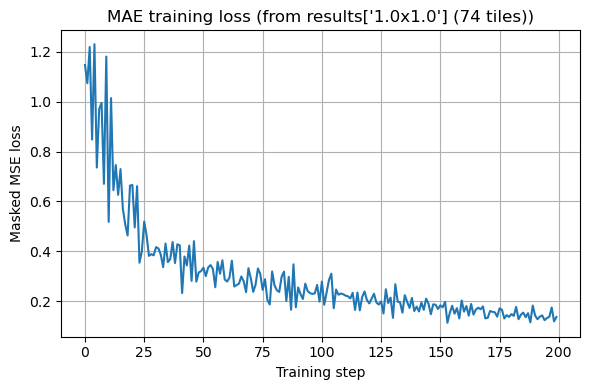

In [58]:
# --- Configure which resolution of tiles to use from your `results` dict ---
TILE_KEY = "1.0x1.0"   # change to "0.25x0.25", "3x3", etc. if you prefer

# --- Collect tiles strictly from results[TILE_KEY] ---
def collect_tiles_from_results(results, tile_key="1x1"):
    if "results" not in globals():
        raise NameError("`results` dict not found. Make sure you've built it with extract_square().")
    if tile_key not in results:
        raise KeyError(f"`results['{tile_key}']` not found. Available keys: {list(results.keys())}")
    if not isinstance(results[tile_key], (list, tuple)) or len(results[tile_key]) == 0:
        raise ValueError(f"`results['{tile_key}']` is empty. Build tiles first with your extract_square loop.")
    tiles = []
    for i, ds in enumerate(results[tile_key]):
        if "elevation" not in ds:
            raise KeyError(f"Tile {i} in results['{tile_key}'] has no 'elevation' variable.")
        arr = np.asarray(ds["elevation"].values, dtype=np.float32)
        if arr.ndim != 2:
            raise ValueError(f"Tile {i} is not 2D (shape {arr.shape}).")
        tiles.append(arr)
    return tiles, f"from results['{tile_key}'] ({len(tiles)} tiles)"

# --- Use your results tiles, train, and plot the loss ---
tiles, source = collect_tiles_from_results(results, TILE_KEY)
print("Dataset source:", source)

losses, model = train_mae(
    tiles,
    H=32, W=32,           # you can increase for more detail; keep moderate for speed
    mask_ratio=0.75,
    hidden=128,
    batch_size=32,
    steps=200,            # raise to 1000+ for better reconstructions
    lr=1e-3,
    weight_decay=1e-4,
    device="cpu"
)

# Plot the losses as a figure
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Masked MSE loss")
plt.title(f"MAE training loss ({source})")
plt.grid(True)
plt.tight_layout()
plt.show()


Training on results['0.1x0.1'] with 57 tiles...
  Final loss (0.1x0.1): 0.071752
Training on results['0.25x0.25'] with 69 tiles...
  Final loss (0.25x0.25): 0.088731
Training on results['1.0x1.0'] with 74 tiles...
  Final loss (1.0x1.0): 0.136727
Training on results['3.0x3.0'] with 47 tiles...
  Final loss (3.0x3.0): 0.093215
Training on results['10.0x10.0'] with 53 tiles...
  Final loss (10.0x10.0): 0.080135


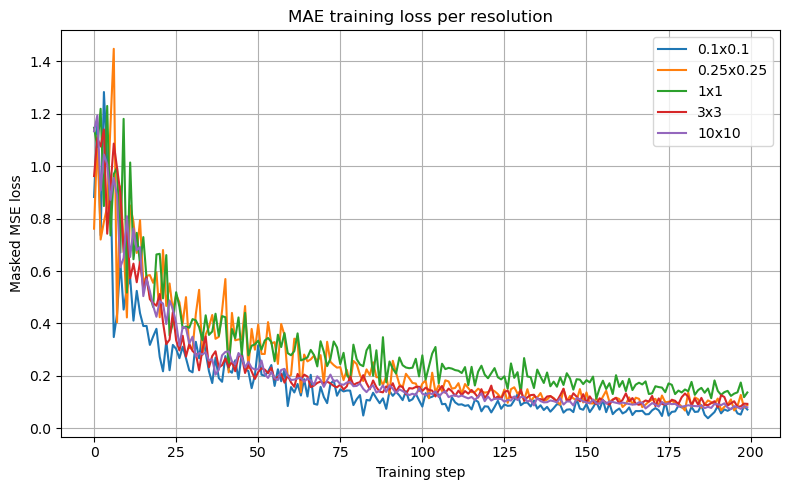

In [59]:
# Train on ALL resolutions found in `results` and plot the loss curves.

import numpy as np
import matplotlib.pyplot as plt

def collect_tiles_from_results(results, tile_key):
    if tile_key not in results or not results[tile_key]:
        raise ValueError(f"`results['{tile_key}']` missing or empty.")
    tiles = []
    for i, ds in enumerate(results[tile_key]):
        if "elevation" not in ds:
            raise KeyError(f"Tile {i} in results['{tile_key}'] has no 'elevation'.")
        arr = np.asarray(ds["elevation"].values, dtype=np.float32)
        if arr.ndim != 2:
            raise ValueError(f"Tile {i} is not 2D (shape {arr.shape}).")
        tiles.append(arr)
    return tiles

# Friendly label normalizer (e.g. '1.0x1.0' -> '1x1')
def norm_label(k):
    try:
        a, b = k.split("x")
        a = str(float(a)).rstrip("0").rstrip(".")
        b = str(float(b)).rstrip("0").rstrip(".")
        return f"{a}x{b}"
    except Exception:
        return k

# Hyperparameters (shared across resolutions)
H, W = 32, 32
mask_ratio = 0.75
hidden = 128
batch_size = 32
steps = 200
lr = 1e-3
weight_decay = 1e-4
device = "cpu"

# Determine iteration order (use a nice order if keys exist)
preferred = ["0.1x0.1", "0.25x0.25", "1x1", "1.0x1.0", "3x3", "10x10"]
ordered_keys = [k for k in preferred if k in results] + [k for k in results.keys() if k not in preferred]

all_losses = {}
all_models = {}

for k in ordered_keys:
    try:
        tiles = collect_tiles_from_results(results, k)
        print(f"Training on results['{k}'] with {len(tiles)} tiles...")
        losses, model = train_mae(
            tiles,
            H=H, W=W,
            mask_ratio=mask_ratio,
            hidden=hidden,
            batch_size=batch_size,
            steps=steps,
            lr=lr,
            weight_decay=weight_decay,
            device=device
        )
        all_losses[k] = losses
        all_models[k] = model
        print(f"  Final loss ({k}): {losses[-1]:.6f}")
    except Exception as e:
        print(f"Skipping '{k}': {e}")

# Plot all loss curves
plt.figure(figsize=(8, 5))
for k, losses in all_losses.items():
    plt.plot(losses, label=norm_label(k))
plt.xlabel("Training step")
plt.ylabel("Masked MSE loss")
plt.title("MAE training loss per resolution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Total tiles collected across all resolutions: 300


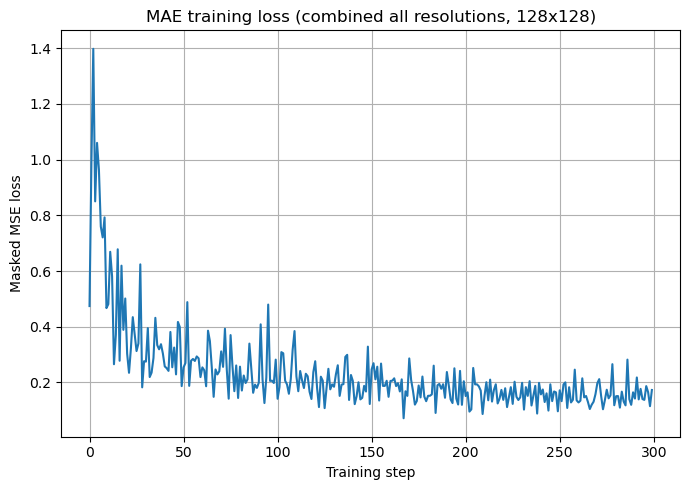

In [71]:
# Combine all resolutions, resize to 128x128 in the dataset, train one model, plot the loss curve.
import numpy as np

def collect_all_tiles_from_results(results):
    """
    Gather every 2D 'elevation' tile from all buckets in `results`.
    Returns a Python list of 2D float32 arrays (with NaNs allowed).
    """
    if "results" not in globals():
        raise NameError("`results` dict not found. Build it with your extract_square() loop first.")

    tiles = []
    empty_keys = []
    for k, items in results.items():
        if not items:
            empty_keys.append(k)
            continue
        for i, ds in enumerate(items):
            if "elevation" not in ds:
                raise KeyError(f"Tile {i} in results['{k}'] has no 'elevation'.")
            arr = np.asarray(ds["elevation"].values, dtype=np.float32)
            if arr.ndim != 2:
                raise ValueError(f"Tile {i} in results['{k}'] is not 2D (shape {arr.shape}).")
            tiles.append(arr)
    if not tiles:
        raise ValueError(f"No tiles found. Empty buckets: {empty_keys}")
    return tiles

# 1) Gather tiles from all buckets
all_tiles = collect_all_tiles_from_results(results)
print(f"Total tiles collected across all resolutions: {len(all_tiles)}")

# 2) Train a single model (set H=W=128 to upscale all inputs)
H = W = 128
mask_ratio = 0.9
hidden = 256        # a touch larger since D=128*128; tweak as you like
batch_size = 36   # reduce if you hit memory limits
steps = 300        # increase for better convergence
lr =1e-3 #1e-3
weight_decay = 1e-4
device = "cpu"      # 'cuda' if available

losses, model = train_mae(
    all_tiles,
    H=H, W=W,
    mask_ratio=mask_ratio,
    hidden=hidden,
    batch_size=batch_size,
    steps=steps,
    lr=lr,
    weight_decay=weight_decay,
    device=device
)

# 3) Plot the single training loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Masked MSE loss")
plt.title(f"MAE training loss (combined all resolutions, {H}x{W})")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Cell 1: Imports & data helpers

import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ----- Utilities -----

def resize_bilinear(img, new_h, new_w):
    """Vectorized bilinear resize for 2D arrays; NaNs interpolate as NaN-weighted (fine for mask usage)."""
    H, W = img.shape
    if H == new_h and W == new_w:
        return img.copy()
    yi = np.linspace(0, H - 1, new_h)
    xi = np.linspace(0, W - 1, new_w)
    y0 = np.floor(yi).astype(int); y1 = np.minimum(y0 + 1, H - 1)
    x0 = np.floor(xi).astype(int); x1 = np.minimum(x0 + 1, W - 1)
    wy = (yi - y0)[:, None]
    wx = (xi - x0)[None, :]
    I00 = img[y0[:, None], x0[None, :]]
    I01 = img[y0[:, None], x1[None, :]]
    I10 = img[y1[:, None], x0[None, :]]
    I11 = img[y1[:, None], x1[None, :]]
    out = (1 - wy) * ((1 - wx) * I00 + wx * I01) + wy * ((1 - wx) * I10 + wx * I11)
    return out

def collect_all_tiles_from_results(results):
    """
    Gather every 2D 'elevation' tile from all buckets in `results`.
    Returns a Python list of 2D float32 arrays (with NaNs allowed).
    """
    if "results" not in globals():
        raise NameError("`results` dict not found. Build it with your extract_square() loop first.")
    tiles = []
    for k, items in results.items():
        if not items:
            continue
        for i, ds in enumerate(items):
            if "elevation" not in ds:
                raise KeyError(f"Tile {i} in results['{k}'] has no 'elevation'.")
            arr = np.asarray(ds["elevation"].values, dtype=np.float32)
            if arr.ndim != 2:
                raise ValueError(f"Tile {i} in results['{k}'] is not 2D (shape {arr.shape}).")
            tiles.append(arr)
    if not tiles:
        raise ValueError("No tiles found in any results bucket.")
    return tiles

# ----- Dataset -----

class CombinedTileDataset(torch.utils.data.Dataset):
    """
    Loads all tiles, resizes to HxW (default 128x128), keeps a 'valid' mask for non-NaN pixels,
    and normalizes the data globally over valid pixels only.
    """
    def __init__(self, tiles, H=128, W=128):
        self.H, self.W = H, W

        X_list, V_list = [], []
        for img in tiles:
            img_r = resize_bilinear(np.asarray(img, dtype=np.float32), H, W)
            valid = ~np.isnan(img_r)
            x = np.where(valid, img_r, 0.0).astype(np.float32)
            X_list.append(x)
            V_list.append(valid.astype(np.float32))

        X = np.stack(X_list, 0)  # (N, H, W)
        V = np.stack(V_list, 0)  # (N, H, W)

        # Global mean/std over valid pixels only
        valid_sum = V.sum()
        if valid_sum == 0:
            raise RuntimeError("No valid (non-NaN) pixels found.")
        mean = float((X * V).sum() / valid_sum)
        std = float(np.sqrt((((X - mean) * V) ** 2).sum() / valid_sum))
        X = (X - mean) / (std + 1e-8)

        # Save tensors: channelize to (N, 1, H, W)
        self.X = torch.from_numpy(X[:, None, :, :])  # (N,1,H,W)
        self.V = torch.from_numpy(V[:, None, :, :])  # (N,1,H,W)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.V[idx]  # (1,H,W), (1,H,W)
    
# Cell 2: MAE model (ViT-style)

class PatchEmbed(nn.Module):
    """Image to patch embeddings using Conv2d (channel=1)."""
    def __init__(self, img_size=128, patch_size=16, in_chans=1, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B,1,H,W) -> (B, embed_dim, h, w) -> (B, N, embed_dim)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x  # (B, N, D)

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, attn_drop=0.0, drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=attn_drop, batch_first=True)
        self.drop1 = nn.Dropout(drop)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hidden, dim),
            nn.Dropout(drop),
        )

    def forward(self, x):
        # x: (B, N, D)
        h = x
        x = self.norm1(x)
        x, _ = self.attn(x, x, x, need_weights=False)
        x = h + self.drop1(x)

        h = x
        x = self.norm2(x)
        x = h + self.mlp(x)
        return x

def random_masking(x, mask_ratio, generator=None):
    """
    x: (B, N, D) patch embeddings
    Returns:
      x_kept: (B, Nk, D)
      mask: (B, N) with 1 for masked, 0 for kept
      ids_restore: (B, N) indices to reassemble original ordering
    """
    B, N, D = x.shape
    if generator is None:
        noise = torch.rand(B, N, device=x.device)
    else:
        noise = torch.rand(B, N, generator=generator, device=x.device)
    # sort noise for each sample; small -> keep
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    Nk = int((1 - mask_ratio) * N)
    ids_keep = ids_shuffle[:, :Nk]
    x_kept = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))
    # mask: 0 for kept, 1 for removed
    mask = torch.ones(B, N, device=x.device)
    mask[:, :Nk] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)
    return x_kept, mask, ids_restore

class MAEViT(nn.Module):
    """
    A compact ViT-style MAE:
      - Encoder: patch embed + positional embed + Transformer blocks
      - Decoder: linear up-embed + positional embed + Transformer blocks
      - Reconstruct pixels for each patch
    """
    def __init__(
        self,
        img_size=128,
        patch_size=16,
        in_chans=1,
        embed_dim=256,
        depth=4,
        num_heads=8,
        decoder_embed_dim=256,
        decoder_depth=2,
        decoder_num_heads=8,
        mlp_ratio=4.0,
        mask_ratio=0.75,
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio

        # Patchify
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.num_patches = self.patch_embed.num_patches
        # Positional embeddings (encoder)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Encoder blocks
        self.encoder = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.enc_norm = nn.LayerNorm(embed_dim)

        # Decoder
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, decoder_embed_dim))
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

        self.decoder = nn.ModuleList([
            TransformerBlock(decoder_embed_dim, decoder_num_heads, mlp_ratio) for _ in range(decoder_depth)
        ])
        self.dec_norm = nn.LayerNorm(decoder_embed_dim)

        # Prediction head: reconstruct patch pixels
        patch_pixels = patch_size * patch_size
        self.head = nn.Linear(decoder_embed_dim, patch_pixels, bias=True)

    def forward(self, x, generator=None):
        """
        x: (B,1,H,W), normalized
        Returns: reconstructed patches (B, N, P^2), mask (B, N)
        """
        B = x.shape[0]
        # ---- Encoder ----
        x = self.patch_embed(x)                          # (B, N, D)
        x = x + self.pos_embed                           # add pos enc
        x_kept, mask, ids_restore = random_masking(x, self.mask_ratio, generator=generator)

        for blk in self.encoder:
            x_kept = blk(x_kept)
        x_kept = self.enc_norm(x_kept)

        # ---- Decoder ----
        dec = self.decoder_embed(x_kept)                 # (B, Nk, Dd)

        # prepare full-length tokens by inserting mask tokens
        Nk = dec.shape[1]
        N = self.num_patches
        mask_tokens = self.mask_token.expand(B, N - Nk, -1)   # (B, Nm, Dd)

        # Reassemble: put back kept+masked to original order
        dec_ = torch.cat([dec, mask_tokens], dim=1)           # (B, N, Dd) (shuffled order)
        # ids_restore maps original positions -> shuffled index; invert to original order
        dec = torch.gather(dec_, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, dec_.shape[-1]))

        dec = dec + self.decoder_pos_embed

        for blk in self.decoder:
            dec = blk(dec)
        dec = self.dec_norm(dec)

        # predict patch pixels
        pred = self.head(dec)                                # (B, N, P^2)
        return pred, mask

    # --- Helpers for loss ---
    def patchify(self, imgs):
        """
        imgs: (B,1,H,W) -> (B, N, P^2)
        """
        p = self.patch_size
        B, C, H, W = imgs.shape
        assert H == self.img_size and W == self.img_size
        h = H // p
        w = W // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = x.permute(0, 2, 4, 3, 5, 1).reshape(B, h*w, p*p*C)
        return x

    def unpatchify(self, patches):
        """
        patches: (B, N, P^2) -> (B,1,H,W)
        """
        p = self.patch_size
        B, N, D = patches.shape
        h = w = int(math.sqrt(N))
        assert h * w == N
        x = patches.reshape(B, h, w, p, p, 1)
        x = x.permute(0, 5, 1, 3, 2, 4).reshape(B, 1, h*p, w*p)
        return x



In [ ]:
def train_mae(
    tiles, H=32, W=32, mask_ratio=0.75,
    hidden=128, batch_size=32, steps=200,
    lr=1e-3, weight_decay=1e-4, seed=0, device="cpu"
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    ds = TileDataset(tiles, H=H, W=W, mask_ratio=mask_ratio, seed=seed)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = TinyMAE(D=H*W, hidden=hidden).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    it = iter(loader)
    losses = []

    for step in range(1, steps + 1):
        try:
            x, v, m = next(it)
        except StopIteration:
            it = iter(loader)
            x, v, m = next(it)

        x, v, m = x.to(device), v.to(device), m.to(device)
        xin = x * (1.0 - m)
        y = model(xin)

        M = m * v
        denom = M.sum().clamp_min(1e-8)
        loss = ((y - x) ** 2 * M).sum() / denom

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        losses.append(loss.item())

    return losses, model

# Example run (uses your real tiles if available, else synthetic)
try:
    tiles, source = try_collect_tiles_from_results()
except Exception:
    tiles, source = make_synthetic_tiles(n=64, h=64, w=64, seed=0)

losses, model = train_mae(
    tiles,
    H=32, W=32,
    mask_ratio=0.75,
    hidden=128,
    batch_size=32,
    steps=200,
    lr=1e-3,
    weight_decay=1e-4,
    device="cpu"
)

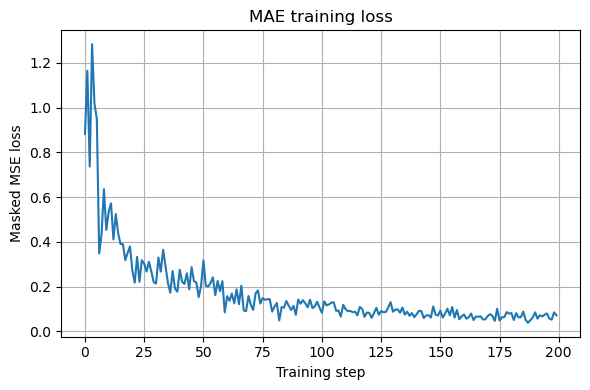

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Masked MSE loss")
plt.title("MAE training loss")
plt.grid(True)
plt.tight_layout()
plt.show()


In [74]:
# Cell 1: Imports & data helpers

import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ----- Utilities -----

def resize_bilinear(img, new_h, new_w):
    """Vectorized bilinear resize for 2D arrays; NaNs interpolate as NaN-weighted (fine for mask usage)."""
    H, W = img.shape
    if H == new_h and W == new_w:
        return img.copy()
    yi = np.linspace(0, H - 1, new_h)
    xi = np.linspace(0, W - 1, new_w)
    y0 = np.floor(yi).astype(int); y1 = np.minimum(y0 + 1, H - 1)
    x0 = np.floor(xi).astype(int); x1 = np.minimum(x0 + 1, W - 1)
    wy = (yi - y0)[:, None]
    wx = (xi - x0)[None, :]
    I00 = img[y0[:, None], x0[None, :]]
    I01 = img[y0[:, None], x1[None, :]]
    I10 = img[y1[:, None], x0[None, :]]
    I11 = img[y1[:, None], x1[None, :]]
    out = (1 - wy) * ((1 - wx) * I00 + wx * I01) + wy * ((1 - wx) * I10 + wx * I11)
    return out

def collect_all_tiles_from_results(results):
    """
    Gather every 2D 'elevation' tile from all buckets in `results`.
    Returns a Python list of 2D float32 arrays (with NaNs allowed).
    """
    if "results" not in globals():
        raise NameError("`results` dict not found. Build it with your extract_square() loop first.")
    tiles = []
    for k, items in results.items():
        if not items:
            continue
        for i, ds in enumerate(items):
            if "elevation" not in ds:
                raise KeyError(f"Tile {i} in results['{k}'] has no 'elevation'.")
            arr = np.asarray(ds["elevation"].values, dtype=np.float32)
            if arr.ndim != 2:
                raise ValueError(f"Tile {i} in results['{k}'] is not 2D (shape {arr.shape}).")
            tiles.append(arr)
    if not tiles:
        raise ValueError("No tiles found in any results bucket.")
    return tiles

# ----- Dataset -----

class CombinedTileDataset(torch.utils.data.Dataset):
    """
    Loads all tiles, resizes to HxW (default 128x128), keeps a 'valid' mask for non-NaN pixels,
    and normalizes the data globally over valid pixels only.
    """
    def __init__(self, tiles, H=128, W=128):
        self.H, self.W = H, W

        X_list, V_list = [], []
        for img in tiles:
            img_r = resize_bilinear(np.asarray(img, dtype=np.float32), H, W)
            valid = ~np.isnan(img_r)
            x = np.where(valid, img_r, 0.0).astype(np.float32)
            X_list.append(x)
            V_list.append(valid.astype(np.float32))

        X = np.stack(X_list, 0)  # (N, H, W)
        V = np.stack(V_list, 0)  # (N, H, W)

        # Global mean/std over valid pixels only
        valid_sum = V.sum()
        if valid_sum == 0:
            raise RuntimeError("No valid (non-NaN) pixels found.")
        mean = float((X * V).sum() / valid_sum)
        std = float(np.sqrt((((X - mean) * V) ** 2).sum() / valid_sum))
        X = (X - mean) / (std + 1e-8)

        # Save tensors: channelize to (N, 1, H, W)
        self.X = torch.from_numpy(X[:, None, :, :])  # (N,1,H,W)
        self.V = torch.from_numpy(V[:, None, :, :])  # (N,1,H,W)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.V[idx]  # (1,H,W), (1,H,W)

# Cell 2: MAE model (ViT-style)

class PatchEmbed(nn.Module):
    """Image to patch embeddings using Conv2d (channel=1)."""
    def __init__(self, img_size=128, patch_size=16, in_chans=1, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B,1,H,W) -> (B, embed_dim, h, w) -> (B, N, embed_dim)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x  # (B, N, D)

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, attn_drop=0.0, drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=attn_drop, batch_first=True)
        self.drop1 = nn.Dropout(drop)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hidden, dim),
            nn.Dropout(drop),
        )

    def forward(self, x):
        # x: (B, N, D)
        h = x
        x = self.norm1(x)
        x, _ = self.attn(x, x, x, need_weights=False)
        x = h + self.drop1(x)

        h = x
        x = self.norm2(x)
        x = h + self.mlp(x)
        return x

def random_masking(x, mask_ratio, generator=None):
    """
    x: (B, N, D) patch embeddings
    Returns:
      x_kept: (B, Nk, D)
      mask: (B, N) with 1 for masked, 0 for kept
      ids_restore: (B, N) indices to reassemble original ordering
    """
    B, N, D = x.shape
    if generator is None:
        noise = torch.rand(B, N, device=x.device)
    else:
        noise = torch.rand(B, N, generator=generator, device=x.device)
    # sort noise for each sample; small -> keep
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    Nk = int((1 - mask_ratio) * N)
    ids_keep = ids_shuffle[:, :Nk]
    x_kept = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))
    # mask: 0 for kept, 1 for removed
    mask = torch.ones(B, N, device=x.device)
    mask[:, :Nk] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)
    return x_kept, mask, ids_restore

class MAEViT(nn.Module):
    """
    A compact ViT-style MAE:
      - Encoder: patch embed + positional embed + Transformer blocks
      - Decoder: linear up-embed + positional embed + Transformer blocks
      - Reconstruct pixels for each patch
    """
    def __init__(
        self,
        img_size=128,
        patch_size=16,
        in_chans=1,
        embed_dim=256,
        depth=4,
        num_heads=8,
        decoder_embed_dim=256,
        decoder_depth=2,
        decoder_num_heads=8,
        mlp_ratio=4.0,
        mask_ratio=0.75,
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio

        # Patchify
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.num_patches = self.patch_embed.num_patches
        # Positional embeddings (encoder)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Encoder blocks
        self.encoder = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.enc_norm = nn.LayerNorm(embed_dim)

        # Decoder
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, decoder_embed_dim))
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

        self.decoder = nn.ModuleList([
            TransformerBlock(decoder_embed_dim, decoder_num_heads, mlp_ratio) for _ in range(decoder_depth)
        ])
        self.dec_norm = nn.LayerNorm(decoder_embed_dim)

        # Prediction head: reconstruct patch pixels
        patch_pixels = patch_size * patch_size
        self.head = nn.Linear(decoder_embed_dim, patch_pixels, bias=True)

    def forward(self, x, generator=None):
        """
        x: (B,1,H,W), normalized
        Returns: reconstructed patches (B, N, P^2), mask (B, N)
        """
        B = x.shape[0]
        # ---- Encoder ----
        x = self.patch_embed(x)                          # (B, N, D)
        x = x + self.pos_embed                           # add pos enc
        x_kept, mask, ids_restore = random_masking(x, self.mask_ratio, generator=generator)

        for blk in self.encoder:
            x_kept = blk(x_kept)
        x_kept = self.enc_norm(x_kept)

        # ---- Decoder ----
        dec = self.decoder_embed(x_kept)                 # (B, Nk, Dd)

        # prepare full-length tokens by inserting mask tokens
        Nk = dec.shape[1]
        N = self.num_patches
        mask_tokens = self.mask_token.expand(B, N - Nk, -1)   # (B, Nm, Dd)

        # Reassemble: put back kept+masked to original order
        dec_ = torch.cat([dec, mask_tokens], dim=1)           # (B, N, Dd) (shuffled order)
        # ids_restore maps original positions -> shuffled index; invert to original order
        dec = torch.gather(dec_, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, dec_.shape[-1]))

        dec = dec + self.decoder_pos_embed

        for blk in self.decoder:
            dec = blk(dec)
        dec = self.dec_norm(dec)

        # predict patch pixels
        pred = self.head(dec)                                # (B, N, P^2)
        return pred, mask

    # --- Helpers for loss ---
    def patchify(self, imgs):
        """
        imgs: (B,1,H,W) -> (B, N, P^2)
        """
        p = self.patch_size
        B, C, H, W = imgs.shape
        assert H == self.img_size and W == self.img_size
        h = H // p
        w = W // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = x.permute(0, 2, 4, 3, 5, 1).reshape(B, h*w, p*p*C)
        return x

    def unpatchify(self, patches):
        """
        patches: (B, N, P^2) -> (B,1,H,W)
        """
        p = self.patch_size
        B, N, D = patches.shape
        h = w = int(math.sqrt(N))
        assert h * w == N
        x = patches.reshape(B, h, w, p, p, 1)
        x = x.permute(0, 5, 1, 3, 2, 4).reshape(B, 1, h*p, w*p)
        return x


step    1 | loss = 0.943291
step   50 | loss = 0.716495
step  100 | loss = 0.253961
step  150 | loss = 0.275952
step  200 | loss = 0.761644
step  250 | loss = 0.362602
step  300 | loss = 0.271561


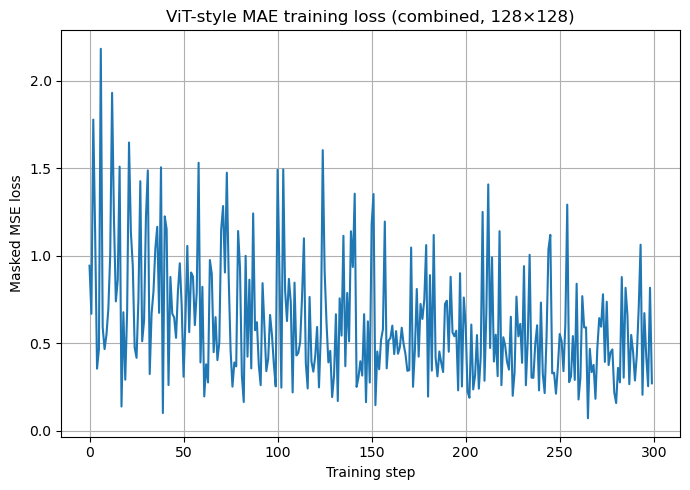

In [76]:
# Cell 3: Train on combined dataset (all resolutions), resize to 128x128, plot losses

import matplotlib.pyplot as plt

def train_mae_vit(
    results,
    img_size=128,
    patch_size=16,
    mask_ratio=0.75,
    embed_dim=256,
    depth=4,
    num_heads=8,
    decoder_embed_dim=256,
    decoder_depth=2,
    decoder_num_heads=8,
    batch_size=16,
    steps=300,
    lr=1e-4,
    weight_decay=0.05,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    tiles = collect_all_tiles_from_results(results)
    ds = CombinedTileDataset(tiles, H=img_size, W=img_size)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = MAEViT(
        img_size=img_size,
        patch_size=patch_size,
        in_chans=1,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        decoder_embed_dim=decoder_embed_dim,
        decoder_depth=decoder_depth,
        decoder_num_heads=decoder_num_heads,
        mask_ratio=mask_ratio,
    ).to(device)

    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Precompute a per-patch "valid" mask for loss weighting (masked & valid only)
    # We'll compute it on the fly per batch by patchifying the validity map.
    losses = []
    it = iter(loader)
    g = torch.Generator(device=device)
    g.manual_seed(seed)

    for step in range(1, steps + 1):
        try:
            x, v = next(it)      # x,v: (B,1,H,W)
        except StopIteration:
            it = iter(loader)
            x, v = next(it)

        x = x.to(device, non_blocking=True)
        v = v.to(device, non_blocking=True)

        # Forward MAE: returns predictions per patch
        pred, mask = model(x, generator=g)         # pred: (B,N,P^2), mask: (B,N)

        # Build targets per patch from input
        target_patches = model.patchify(x)         # (B,N,P^2)

        # Build valid-per-patch weighting from pixel valid mask:
        # A patch is partially valid; we weight each pixel by its validity.
        valid_patches = model.patchify(v)          # (B,N,P^2), 0/1
        # Loss on masked patches only (mask==1). Expand mask over patch pixels:
        patch_mask = mask.unsqueeze(-1)            # (B,N,1)

        # Weighted MSE: (pred - target)^2 * (valid) * (masked)
        diff2 = (pred - target_patches) ** 2
        num = (diff2 * valid_patches * patch_mask).sum()
        denom = (valid_patches * patch_mask).sum().clamp_min(1e-8)
        loss = num / denom

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        losses.append(loss.item())

        if step == 1 or step % 50 == 0 or step == steps:
            print(f"step {step:4d} | loss = {loss.item():.6f}")

    return losses, model

# ---- Run training (combined data) ----
losses_vit, model_vit = train_mae_vit(
    results,
    img_size=256,
    patch_size=16,       # 8x8 = 64 patches; change to 8 for 16x16 = 256 patches
    mask_ratio=0.75,
    embed_dim=256*2,
    depth=4,
    num_heads=8,
    decoder_embed_dim=256,
    decoder_depth=2,
    decoder_num_heads=8,
    batch_size=16,       # adjust for your GPU/CPU memory
    steps=300,           # raise for better convergence
    lr=1e-4,
    weight_decay=0.05,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=0,
)

# ---- Plot loss curve ----
plt.figure(figsize=(7, 5))
plt.plot(losses_vit)
plt.xlabel("Training step")
plt.ylabel("Masked MSE loss")
plt.title("ViT-style MAE training loss (combined, 128×128)")
plt.grid(True)
plt.tight_layout()
plt.show()

step    1 | loss = 17.558842 | mse_edge=11.768934 | grad=5.789907
step   50 | loss = 5.772228 | mse_edge=2.762082 | grad=3.010147
step  100 | loss = 14.750697 | mse_edge=8.306333 | grad=6.444365


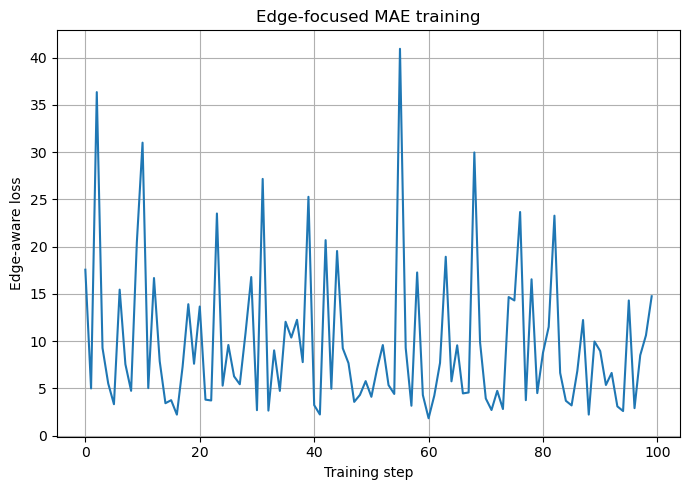

In [82]:
# Edge-aware training for the ViT-style MAE (drop-in replacement for train_mae_vit)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def sobel_filters(device):
    # 1-channel Sobel kernels
    kx = torch.tensor([[-1, 0, 1],
                       [-2, 0, 2],
                       [-1, 0, 1]], dtype=torch.float32, device=device).view(1,1,3,3)
    ky = torch.tensor([[-1,-2,-1],
                       [ 0, 0, 0],
                       [ 1, 2, 1]], dtype=torch.float32, device=device).view(1,1,3,3)
    return kx, ky

@torch.no_grad()
def edge_magnitude(x, kx, ky):
    # x: (B,1,H,W) normalized image
    gx = F.conv2d(x, kx, padding=1)
    gy = F.conv2d(x, ky, padding=1)
    mag = torch.sqrt(gx*gx + gy*gy + 1e-8)
    return mag, gx, gy

def expand_patch_mask(mask_patches, H, W, patch_size):
    """
    mask_patches: (B, N) with 1 = masked, 0 = kept
    returns mask_px: (B,1,H,W) with same 0/1 semantics, tiled per patch
    """
    B, N = mask_patches.shape
    h = H // patch_size
    w = W // patch_size
    assert h*w == N, "patch grid mismatch"
    m = mask_patches.view(B, 1, h, w).repeat_interleave(patch_size, 2).repeat_interleave(patch_size, 3)
    return m  # (B,1,H,W)

def train_mae_vit_edges(
    results,
    model,                          # your MAEViT instance
    img_size=128,
    patch_size=16,
    mask_ratio=0.75,
    batch_size=16,
    steps=300,
    lr=1e-4,
    weight_decay=0.05,
    # Edge-focused loss knobs:
    lambda_grad=1.0,                # weight on gradient-matching loss
    edge_focus=2.0,                 # exponent for edge-weighting (>=1 makes edges count more)
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    tiles = collect_all_tiles_from_results(results)
    ds = CombinedTileDataset(tiles, H=img_size, W=img_size)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = model.to(device)
    model.mask_ratio = mask_ratio  # ensure current ratio is used inside forward
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    kx, ky = sobel_filters(device)
    losses = []
    it = iter(loader)
    g = torch.Generator(device=device); g.manual_seed(seed)

    for step in range(1, steps + 1):
        try:
            x, v = next(it)  # (B,1,H,W), (B,1,H,W)
        except StopIteration:
            it = iter(loader)
            x, v = next(it)

        x = x.to(device, non_blocking=True)
        v = v.to(device, non_blocking=True)

        # Forward: predicted patch pixels + patch mask
        pred, mask_p = model(x, generator=g)                # pred: (B,N,P^2), mask_p: (B,N)
        target_patches = model.patchify(x)                  # (B,N,P^2)
        valid_patches = model.patchify(v)                   # (B,N,P^2), 0/1

        # --- Edge-weighted masked MSE (in patch space) ---
        # Edge magnitude from target in pixel space, then patchify
        with torch.no_grad():
            mag_t, _, _ = edge_magnitude(x, kx, ky)         # (B,1,H,W)
            # Normalize edge map so avg weight ~1
            mag_norm = mag_t / (mag_t.mean(dim=(1,2,3), keepdim=True) + 1e-8)
            # Emphasize edges
            edge_w_px = mag_norm.clamp(min=0).pow(edge_focus)  # (B,1,H,W)
            edge_w_p  = model.patchify(edge_w_px)              # (B,N,P^2)
            # Expand mask to patch pixels
            patch_mask = mask_p.unsqueeze(-1)                  # (B,N,1)

        diff2 = (pred - target_patches) ** 2
        num_pix = (valid_patches * patch_mask).sum().clamp_min(1e-8)
        # weighted MSE
        mse_edge = (diff2 * valid_patches * patch_mask * edge_w_p).sum() / (edge_w_p * valid_patches * patch_mask).sum().clamp_min(1e-8)

        # --- Gradient matching loss (in pixel space), also edge-weighted & masked ---
        # Unpatchify to image space
        rec = model.unpatchify(pred)                         # (B,1,H,W)
        # Build pixel-space mask of masked patches
        mask_px = expand_patch_mask(mask_p, img_size, img_size, patch_size)  # (B,1,H,W)
        # Compute gradients
        mag_r, _, _ = edge_magnitude(rec, kx, ky)           # (B,1,H,W)
        # Valid+masked region
        region = v * mask_px
        denom_grad = (region * edge_w_px).sum().clamp_min(1e-8)
        grad_l1 = ((mag_r - mag_t).abs() * region * edge_w_px).sum() / denom_grad

        loss = mse_edge + lambda_grad * grad_l1

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        losses.append(loss.item())
        if step == 1 or step % 50 == 0 or step == steps:
            print(f"step {step:4d} | loss = {loss.item():.6f} | mse_edge={mse_edge.item():.6f} | grad={grad_l1.item():.6f}")

    return losses, model

# ---- Example run (combined dataset, 128x128, edge-aware) ----
# Reuse your MAEViT config; smaller patches help edges.
mae_edge = MAEViT(
    img_size=128,
    patch_size=8,            # smaller patch -> finer edge handling
    embed_dim=256,
    depth=6,
    num_heads=8,
    decoder_embed_dim=256,
    decoder_depth=3,
    decoder_num_heads=8,
    mask_ratio=0.75,
)

losses_edge, model_edge = train_mae_vit_edges(
    results,
    mae_edge,
    img_size=128,
    patch_size=8,
    mask_ratio=0.75,
    batch_size=16,
    steps=100,
    lr=1e-5,
    weight_decay=0.05,
    lambda_grad=1.0,         # try 0.5–2.0
    edge_focus=2.0,          # try 1.5–3.0
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=0,
)

plt.figure(figsize=(7,5))
plt.plot(losses_edge)
plt.xlabel("Training step"); plt.ylabel("Edge-aware loss")
plt.title("Edge-focused MAE training")
plt.grid(True); plt.tight_layout(); plt.show()


results

In [73]:
# ========= masked_autoencoder_bathy.py =========
import math
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# 1) DATA: xarray tiles -> tensors
# -----------------------------
# Expect: `results` is your dict of size buckets (strings like "0.25x0.25") -> list[xr.Dataset]
# Each dataset has a variable "elevation" with NaNs over land.

def _normalize_depth_m1p1(arr, min_depth=-11000.0, max_depth=0.0):
    """Clip to [min_depth, max_depth] and map to [-1, 1]."""
    arr = np.clip(arr, min_depth, max_depth)
    # map [min_depth, max_depth] -> [-1, 1]
    x = (arr - min_depth) / (max_depth - min_depth + 1e-8)  # -> [0,1]
    x = x * 2.0 - 1.0
    return x

def _to_numpy(ds_tile, target_hw=(128, 128)):
    """
    Get elevation (lat x lon) -> numpy float32 (H, W).
    Resamples to target size with simple bilinear-like resize via torch (CPU).
    """
    elev = ds_tile["elevation"].values.astype(np.float32)
    # handle cases where lat is descending
    if ds_tile.lat.values[0] > ds_tile.lat.values[-1]:
        elev = elev[::-1, :]
    # replace NaNs with 0 for the image (we'll carry a validity mask for loss)
    valid = np.isfinite(elev).astype(np.float32)
    elev = np.nan_to_num(elev, nan=0.0)

    # normalize depths to [-1, 1]
    elev = _normalize_depth_m1p1(elev)

    # resize to target_hw using torch (keeps things simple)
    x = torch.from_numpy(elev)[None, None, ...]  # (1,1,H,W)
    v = torch.from_numpy(valid)[None, None, ...]
    x = F.interpolate(x, size=target_hw, mode="bilinear", align_corners=False)
    v = F.interpolate(v, size=target_hw, mode="nearest")
    x = x.squeeze(0).squeeze(0).numpy().astype(np.float32)  # (H,W)
    v = v.squeeze(0).squeeze(0).numpy().astype(np.float32)  # (H,W)
    return x, v

class BathymetryDataset(Dataset):
    def __init__(self, results, sizes=("0.25x0.25","0.1x0.1","1x1","3x3","10x10"),
                 target_hw=(128,128), max_per_bin=None, shuffle=True):
        self.samples = []
        for k in sizes:
            tiles = results.get(k, [])
            if not tiles: 
                continue
            if max_per_bin is not None:
                tiles = tiles[:max_per_bin]
            for ds in tiles:
                self.samples.append((k, ds))
        if shuffle:
            random.shuffle(self.samples)
        self.target_hw = target_hw

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        _, ds = self.samples[idx]
        x, valid = _to_numpy(ds, self.target_hw)
        # return 1-channel image and validity mask
        x = torch.from_numpy(x)[None, ...]        # (1,H,W) in [-1,1]
        valid = torch.from_numpy(valid)[None, ...]# (1,H,W) 1=valid 0=invalid
        return x, valid

# -----------------------------
# 2) MASKING: random block mask
# -----------------------------
class RandomBlockMask:
    """
    Create a binary mask of shape (1,H,W) with a given mask_ratio by placing
    square blocks at random locations until ratio reached. Blocks are ~H/16 size by default.
    """
    def __init__(self, mask_ratio=0.6, block_size=None):
        self.mask_ratio = mask_ratio
        self.block_size = block_size  # if None, adapt from image size

    def __call__(self, x):
        # x: (B,1,H,W) or (1,H,W)
        if x.dim() == 3:
            x = x.unsqueeze(0)
            squeeze_back = True
        else:
            squeeze_back = False
        B, C, H, W = x.shape
        bs = self.block_size or max(4, min(H, W) // 16)

        masks = []
        for _ in range(B):
            m = torch.zeros((1, H, W), dtype=torch.float32)
            target = int(self.mask_ratio * H * W)
            covered = 0
            # random blocks until we cover ~target pixels
            # limit iterations for speed
            for _ in range(5_000):
                if covered >= target:
                    break
                h = min(bs + np.random.randint(-bs//4, bs//4 + 1), H)
                w = min(bs + np.random.randint(-bs//4, bs//4 + 1), W)
                h = max(2, h); w = max(2, w)
                i = np.random.randint(0, max(1, H - h + 1))
                j = np.random.randint(0, max(1, W - w + 1))
                block = m[:, i:i+h, j:j+w]
                newly = (1.0 - block).sum()
                block[:] = 1.0
                covered += int(newly.item())
            masks.append(m)
        mask = torch.stack(masks, dim=0)  # (B,1,H,W)
        if squeeze_back:
            mask = mask.squeeze(0)
        return mask

# -----------------------------
# 3) MODEL: simple Conv encoder-decoder (MAE)
# -----------------------------
class ConvEncoder(nn.Module):
    def __init__(self, in_ch=1, width=64, depth=4):
        super().__init__()
        layers = []
        ch = in_ch
        for i in range(depth):
            layers += [
                nn.Conv2d(ch, width*(2**i), kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(width*(2**i)),
                nn.GELU(),
                nn.Conv2d(width*(2**i), width*(2**i), kernel_size=3, padding=1),
                nn.BatchNorm2d(width*(2**i)),
                nn.GELU(),
            ]
            ch = width*(2**i)
        self.body = nn.Sequential(*layers)

    def forward(self, x):
        # returns latent feature map
        return self.body(x)

class ConvDecoder(nn.Module):
    def __init__(self, out_ch=1, base_ch=64, depth=4):
        super().__init__()
        chs = [base_ch*(2**i) for i in range(depth)][::-1]
        layers = []
        ch = chs[0]
        for i in range(len(chs)-1):
            layers += [
                nn.ConvTranspose2d(ch, chs[i+1], kernel_size=2, stride=2),
                nn.BatchNorm2d(chs[i+1]),
                nn.GELU(),
                nn.Conv2d(chs[i+1], chs[i+1], kernel_size=3, padding=1),
                nn.BatchNorm2d(chs[i+1]),
                nn.GELU(),
            ]
            ch = chs[i+1]
        # final upsample back to original size
        layers += [
            nn.ConvTranspose2d(ch, ch//2, kernel_size=2, stride=2),
            nn.GELU(),
            nn.Conv2d(ch//2, out_ch, kernel_size=3, padding=1),
            nn.Tanh()  # outputs in [-1,1] to match normalized input
        ]
        self.body = nn.Sequential(*layers)

    def forward(self, z):
        return self.body(z)

class ConvMAE(nn.Module):
    """
    Masked autoencoder:
      - Mask the input (set masked pixels to 0)
      - Encode/Decode
      - Compute MSE loss only on masked & valid pixels
    """
    def __init__(self, in_ch=1, width=64, depth=4):
        super().__init__()
        self.encoder = ConvEncoder(in_ch=in_ch, width=width, depth=depth)
        self.decoder = ConvDecoder(out_ch=in_ch, base_ch=width, depth=depth)

    def forward(self, x, mask, valid):
        """
        x: (B,1,H,W) in [-1,1]
        mask: (B,1,H,W) 1 = masked, 0 = visible
        valid: (B,1,H,W) 1 = has data (ocean), 0 = invalid/land
        """
        x_vis = x * (1.0 - mask)   # zero-out masked pixels
        z = self.encoder(x_vis)
        x_hat = self.decoder(z)
        # reconstruction loss on masked & valid pixels
        denom = ((mask * valid).sum(dim=(1,2,3)) + 1e-6)
        per = (((x_hat - x)**2) * mask * valid).sum(dim=(1,2,3)) / denom
        loss = per.mean()
        return x_hat, loss

# -----------------------------
# 4) TRAIN LOOP
# -----------------------------
def train_mae(results,
              sizes=("0.25x0.25","0.1x0.1","1x1","3x3","10x10"),
              target_hw=(128,128),
              batch_size=32,
              epochs=5,
              lr=3e-4,
              mask_ratio=0.6,
              device=None,
              save_dir="mae_bathy"):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    ds = BathymetryDataset(results, sizes=sizes, target_hw=target_hw, max_per_bin=None, shuffle=True)
    if len(ds) == 0:
        raise RuntimeError("Dataset is empty — are there tiles in `results`?")
    n_train = int(0.95 * len(ds))
    n_val = len(ds) - n_train
    train_ds, val_ds = torch.utils.data.random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(0))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    model = ConvMAE(in_ch=1, width=64, depth=4).to(device)
    mask_gen = RandomBlockMask(mask_ratio=mask_ratio)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.05)

    best_val = float("inf")
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    for ep in range(1, epochs+1):
        model.train()
        tr_loss = 0.0
        for x, valid in train_loader:
            x = x.to(device)             # (B,1,H,W)
            valid = valid.to(device)     # (B,1,H,W)
            mask = mask_gen(x).to(device)
            _, loss = model(x, mask, valid)
            opt.zero_grad()
            loss.backward()
            opt.step()
            tr_loss += loss.item() * x.size(0)
        tr_loss /= len(train_loader.dataset)

        # Val
        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for x, valid in val_loader:
                x = x.to(device)
                valid = valid.to(device)
                mask = mask_gen(x).to(device)
                _, loss = model(x, mask, valid)
                va_loss += loss.item() * x.size(0)
        va_loss /= max(1, len(val_loader.dataset))

        print(f"[Epoch {ep:03d}] train {tr_loss:.4f}  val {va_loss:.4f}")

        # Save best encoder
        if va_loss < best_val:
            best_val = va_loss
            torch.save(model.encoder.state_dict(), save_path / "encoder.pth")
            torch.save(model.state_dict(), save_path / "mae_full.pth")
            print(f"  ↳ saved best encoder to {save_path/'encoder.pth'}")

    return model, str(save_path / "encoder.pth")


In [45]:
if __name__ == "__main__":
    # build or load your `results` dict here
    model, enc_path = train_mae(
        results,
        sizes=("0.25x0.25","0.1x0.1","1x1","3x3","10x10"),
        target_hw=(128,128),
        batch_size=64,
        epochs=10,
        lr=3e-4,
        mask_ratio=0.6,
        save_dir="mae_bathy_run1",
    )

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/lb962/miniconda3/envs/ESL/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/lb962/miniconda3/envs/ESL/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'BathymetryDataset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


KeyboardInterrupt: 

In [41]:
# 1) Train MAE (self-supervised)
model, enc_path = train_mae(
    results,
    sizes=("0.25x0.25","0.1x0.1","1x1","3x3","10x10"),
    target_hw=(128,128),
    batch_size=64,
    epochs=10,
    lr=3e-4,
    mask_ratio=0.6,
    save_dir="mae_bathy_run1"
)

# 2) Use encoder as static features
#feat_vec = extract_encoder_features(enc_path, results["0.25x0.25"][0], target_hw=(128,128))
#print("feature dim:", feat_vec.shape)

# 3) (Optional) Fine-tune with a small head
#head = example_finetune(results, enc_path, target_hw=(128,128), out_dim=1)

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/lb962/miniconda3/envs/ESL/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/lb962/miniconda3/envs/ESL/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'BathymetryDataset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


KeyboardInterrupt: 

In [ ]:

# -----------------------------
# 5) USING THE ENCODER AS STATIC FEATURES
# -----------------------------
def extract_encoder_features(encoder_pth, ds_tile, target_hw=(128,128), device=None):
    """
    Load encoder and return a pooled feature vector for one tile.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    enc = ConvEncoder(in_ch=1, width=64, depth=4).to(device)
    enc.load_state_dict(torch.load(encoder_pth, map_location=device))
    enc.eval()
    x, valid = _to_numpy(ds_tile, target_hw)
    x = torch.from_numpy(x)[None, None, ...].to(device)
    with torch.no_grad():
        z = enc(x)             # (B,C,h,w)
        feat = F.adaptive_avg_pool2d(z, 1).squeeze(-1).squeeze(-1)  # (B,C)
    return feat.cpu().numpy()[0]

class FinetuneHead(nn.Module):
    """Example head for regression/classification atop the frozen encoder."""
    def __init__(self, in_ch=64*(2**3), out_dim=1):  # depth=4 -> last ch = 64*2^3=512
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_ch, 256), nn.GELU(),
            nn.Linear(256, out_dim)
        )
    def forward(self, z):  # z is (B,C,h,w)
        x = F.adaptive_avg_pool2d(z, 1).flatten(1)
        return self.mlp(x)

def example_finetune(results, encoder_pth, target_hw=(128,128), out_dim=1, device=None):
    """
    Minimal sketch: freeze encoder, train small head.
    Replace the 'label' with your real target.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    enc = ConvEncoder(in_ch=1, width=64, depth=4).to(device)
    enc.load_state_dict(torch.load(encoder_pth, map_location=device))
    for p in enc.parameters():
        p.requires_grad = False
    head = FinetuneHead(in_ch=64*(2**3), out_dim=out_dim).to(device)

    ds = BathymetryDataset(results, target_hw=target_hw, shuffle=True)
    # Fake labels for demo; plug in your real labels here:
    labels = torch.randn(len(ds), out_dim)
    class Wrap(Dataset):
        def __len__(self): return len(ds)
        def __getitem__(self, i):
            x, valid = ds[i]
            return x, labels[i]
    dl = DataLoader(Wrap(), batch_size=32, shuffle=True)

    opt = torch.optim.AdamW(head.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for ep in range(5):
        head.train()
        for x, y in dl:
            x = x.to(device); y = y.to(device)
            with torch.no_grad():
                z = enc(x)
            yhat = head(z)
            loss = loss_fn(yhat, y)
            opt.zero_grad(); loss.backward(); opt.step()
        print(f"finetune epoch {ep+1} done")
    return head
# ========= end =========
